In [74]:
# Floor Plan Boundary Detection Dataset Generator
# This notebook creates a new YOLO dataset by combining multiple floor plan images
# into single images, with bounding boxes around each complete floor plan


In [75]:
import os
import random
import shutil
from pathlib import Path
import numpy as np
from PIL import Image
import yaml
from tqdm import tqdm


In [76]:
# Source dataset path
SOURCE_DATASET = Path("../data/cubicasa5k-2.v6i.yolov12")

# Output dataset path
OUTPUT_DATASET = Path("../data/floor_plan_detection_dataset")

# Configuration for image combination
MIN_FLOOR_PLANS = 2  # Minimum number of floor plans per combined image
MAX_FLOOR_PLANS = 6  # Maximum number of floor plans per combined image
CANVAS_SIZE = 2048  # Size of the output canvas (square)
PADDING = 20  # Padding between floor plans and canvas edges
BACKGROUND_COLOR = (255, 255, 255)  # White background

# Frame configuration
FRAME_PROBABILITY = 0.8  # Probability of adding frames (80% of images will have frames)
DOUBLE_FRAME_PROBABILITY = 0.5  # Probability of double-line frame vs single-line
FRAME_THICKNESS = 2  # Thickness of frame lines
FRAME_SPACING_MIN = 5  # Minimum spacing between double lines
FRAME_SPACING_MAX = 15  # Maximum spacing between double lines
FRAME_COLOR = (0, 0, 0)  # Black frame
FRAME_MARGIN_MIN = 5  # Minimum space between floor plan and frame
FRAME_MARGIN_MAX = 30  # Maximum space between floor plan and frame
GROUP_FRAME_PROBABILITY = 0.3  # Probability of framing multiple floor plans together

# Dataset split ratios
TRAIN_RATIO = 0.7
VALID_RATIO = 0.15
TEST_RATIO = 0.15

# Number of combined images to generate for each split
NUM_TRAIN_IMAGES = 5000
NUM_VALID_IMAGES = 1000
NUM_TEST_IMAGES = 1000

print(f"Source dataset: {SOURCE_DATASET}")
print(f"Output dataset: {OUTPUT_DATASET}")
print(f"Will generate {NUM_TRAIN_IMAGES + NUM_VALID_IMAGES + NUM_TEST_IMAGES} combined images")


Source dataset: ../data/cubicasa5k-2.v6i.yolov12
Output dataset: ../data/floor_plan_detection_dataset
Will generate 7000 combined images


In [77]:
def create_output_dirs():
    """Create the output directory structure for the new dataset."""
    for split in ['train', 'valid', 'test']:
        (OUTPUT_DATASET / split / 'images').mkdir(parents=True, exist_ok=True)
        (OUTPUT_DATASET / split / 'labels').mkdir(parents=True, exist_ok=True)
    print("✓ Created output directory structure")

create_output_dirs()


✓ Created output directory structure


In [78]:
def load_image_paths(split):
    """Load all available image paths from a dataset split."""
    image_dir = SOURCE_DATASET / split / 'images'
    image_paths = list(image_dir.glob('*.jpg')) + list(image_dir.glob('*.png'))
    return image_paths

train_images = load_image_paths('train')
valid_images = load_image_paths('valid')
test_images = load_image_paths('test')

# Pool all images together for random selection
all_source_images = train_images + valid_images + test_images

print(f"Found {len(train_images)} training images")
print(f"Found {len(valid_images)} validation images")
print(f"Found {len(test_images)} test images")
print(f"Total source images: {len(all_source_images)}")


Found 4178 training images
Found 400 validation images
Found 400 test images
Total source images: 4978


In [79]:
import cv2 as cv

def draw_single_frame(canvas_np, x1, y1, x2, y2, thickness=FRAME_THICKNESS, color=FRAME_COLOR):
    """Draw a single-line rectangular frame."""
    cv.rectangle(canvas_np, (x1, y1), (x2, y2), color, thickness)
    return canvas_np

def draw_double_frame(canvas_np, x1, y1, x2, y2, thickness=FRAME_THICKNESS,
                      spacing=None, color=FRAME_COLOR):
    """Draw a double-line rectangular frame with random spacing."""
    # Use random spacing if not provided
    if spacing is None:
        spacing = random.randint(FRAME_SPACING_MIN, FRAME_SPACING_MAX)

    # Outer frame
    cv.rectangle(canvas_np, (x1, y1), (x2, y2), color, thickness)
    # Inner frame
    inner_offset = spacing + thickness
    cv.rectangle(canvas_np,
                (x1 + inner_offset, y1 + inner_offset),
                (x2 - inner_offset, y2 - inner_offset),
                color, thickness)
    return canvas_np

def draw_frame_around_region(canvas_np, x1, y1, x2, y2, double_frame=False):
    """Draw a frame (single or double) around a region with random spacing."""
    if double_frame:
        return draw_double_frame(canvas_np, x1, y1, x2, y2)
    else:
        return draw_single_frame(canvas_np, x1, y1, x2, y2)

def resize_image_to_fit(image, max_width, max_height):
    """Resize image to fit within max dimensions while maintaining aspect ratio."""
    width, height = image.size
    ratio = min(max_width / width, max_height / height)

    if ratio < 1:  # Only resize if image is larger than max dimensions
        new_width = int(width * ratio)
        new_height = int(height * ratio)
        return image.resize((new_width, new_height), Image.Resampling.LANCZOS)
    return image

def place_images_on_canvas(images, canvas_size, padding):
    """
    Place multiple images on a canvas in a grid layout with optional frames.
    Returns the canvas and bounding boxes in YOLO format.
    """
    canvas = Image.new('RGB', (canvas_size, canvas_size), BACKGROUND_COLOR)
    canvas_np = np.array(canvas)
    bboxes = []
    floor_plan_positions = []  # Store positions for potential group framing

    num_images = len(images)

    # Calculate grid dimensions (roughly square)
    grid_cols = int(np.ceil(np.sqrt(num_images)))
    grid_rows = int(np.ceil(num_images / grid_cols))

    # Calculate cell dimensions
    cell_width = (canvas_size - padding * (grid_cols + 1)) // grid_cols
    cell_height = (canvas_size - padding * (grid_rows + 1)) // grid_rows

    # Decide if we'll add frames
    add_frames = random.random() < FRAME_PROBABILITY

    for idx, img in enumerate(images):
        # Calculate grid position
        row = idx // grid_cols
        col = idx % grid_cols

        # Resize image to fit in cell
        resized_img = resize_image_to_fit(img, cell_width, cell_height)
        img_width, img_height = resized_img.size

        # Calculate position (center in cell)
        x_offset = padding + col * (cell_width + padding) + (cell_width - img_width) // 2
        y_offset = padding + row * (cell_height + padding) + (cell_height - img_height) // 2

        # Paste image onto canvas
        canvas_np[y_offset:y_offset+img_height, x_offset:x_offset+img_width] = np.array(resized_img)

        # Store position for potential framing
        floor_plan_positions.append({
            'x1': x_offset,
            'y1': y_offset,
            'x2': x_offset + img_width,
            'y2': y_offset + img_height,
            'row': row,
            'col': col
        })

        # Calculate YOLO format bounding box (normalized center x, center y, width, height)
        center_x = (x_offset + img_width / 2) / canvas_size
        center_y = (y_offset + img_height / 2) / canvas_size
        bbox_width = img_width / canvas_size
        bbox_height = img_height / canvas_size

        # Class 0 for "floor_plan"
        bboxes.append([0, center_x, center_y, bbox_width, bbox_height])

    # Add frames if enabled (only when there are at least 2 floor plans)
    if add_frames and num_images >= 2:
        # Decide whether to frame groups or individual plans
        use_group_frames = random.random() < GROUP_FRAME_PROBABILITY

        if use_group_frames:
            # Frame groups of floor plans together (2-3 floor plans per group)
            num_groups = random.randint(1, max(1, num_images // 2))

            # Shuffle and split into groups
            shuffled_indices = list(range(len(floor_plan_positions)))
            random.shuffle(shuffled_indices)

            for group_idx in range(num_groups):
                # Check if we have enough floor plans left to make a group
                if len(shuffled_indices) < 2:
                    break

                # Get 2-3 floor plans for this group
                max_group_size = min(3, len(shuffled_indices))
                group_size = random.randint(2, max_group_size)

                group_indices = [shuffled_indices.pop() for _ in range(group_size)]

                # Find bounding box that contains all floor plans in group
                min_x = min(floor_plan_positions[i]['x1'] for i in group_indices)
                min_y = min(floor_plan_positions[i]['y1'] for i in group_indices)
                max_x = max(floor_plan_positions[i]['x2'] for i in group_indices)
                max_y = max(floor_plan_positions[i]['y2'] for i in group_indices)

                # Add random margin around the group
                frame_margin = random.randint(FRAME_MARGIN_MIN, FRAME_MARGIN_MAX)
                frame_x1 = max(0, min_x - frame_margin)
                frame_y1 = max(0, min_y - frame_margin)
                frame_x2 = min(canvas_size, max_x + frame_margin)
                frame_y2 = min(canvas_size, max_y + frame_margin)

                # Draw frame (randomly choose single or double)
                is_double = random.random() < DOUBLE_FRAME_PROBABILITY
                canvas_np = draw_frame_around_region(canvas_np, frame_x1, frame_y1,
                                                    frame_x2, frame_y2, is_double)
        else:
            # Frame pairs or small groups of floor plans (minimum 2 per frame)
            shuffled_indices = list(range(len(floor_plan_positions)))
            random.shuffle(shuffled_indices)

            while len(shuffled_indices) >= 2:
                # Randomly decide if we should frame the next 2-3 floor plans
                if random.random() < 0.7:  # 70% chance to frame
                    # Get 2-3 floor plans
                    max_group_size = min(3, len(shuffled_indices))
                    group_size = random.randint(2, max_group_size)

                    group_indices = [shuffled_indices.pop() for _ in range(group_size)]

                    # Find bounding box that contains all floor plans
                    min_x = min(floor_plan_positions[i]['x1'] for i in group_indices)
                    min_y = min(floor_plan_positions[i]['y1'] for i in group_indices)
                    max_x = max(floor_plan_positions[i]['x2'] for i in group_indices)
                    max_y = max(floor_plan_positions[i]['y2'] for i in group_indices)

                    # Add random margin (can vary for each frame)
                    frame_margin = random.randint(FRAME_MARGIN_MIN, FRAME_MARGIN_MAX)
                    frame_x1 = max(0, min_x - frame_margin)
                    frame_y1 = max(0, min_y - frame_margin)
                    frame_x2 = min(canvas_size, max_x + frame_margin)
                    frame_y2 = min(canvas_size, max_y + frame_margin)

                    # Draw frame (randomly choose single or double)
                    is_double = random.random() < DOUBLE_FRAME_PROBABILITY
                    canvas_np = draw_frame_around_region(canvas_np, frame_x1, frame_y1,
                                                        frame_x2, frame_y2, is_double)
                else:
                    # Skip framing this group, remove 2 indices
                    if len(shuffled_indices) >= 2:
                        shuffled_indices.pop()
                        shuffled_indices.pop()
                    else:
                        break

    # Convert back to PIL Image
    canvas = Image.fromarray(canvas_np)

    return canvas, bboxes

def generate_combined_image(source_image_paths, num_floor_plans):
    """
    Generate a combined image with multiple floor plans.
    Returns the combined image and YOLO format bounding boxes.
    """
    # Randomly select floor plans
    selected_paths = random.sample(source_image_paths, num_floor_plans)

    # Load images
    images = []
    for path in selected_paths:
        try:
            img = Image.open(path).convert('RGB')
            images.append(img)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            continue

    if len(images) == 0:
        return None, None

    # Place images on canvas
    canvas, bboxes = place_images_on_canvas(images, CANVAS_SIZE, PADDING)

    return canvas, bboxes


In [80]:
def generate_dataset_split(split_name, num_images):
    """Generate combined images and labels for a dataset split."""
    print(f"\nGenerating {split_name} split ({num_images} images)...")

    output_image_dir = OUTPUT_DATASET / split_name / 'images'
    output_label_dir = OUTPUT_DATASET / split_name / 'labels'

    for i in tqdm(range(num_images), desc=f"Creating {split_name} images"):
        # Random number of floor plans
        num_floor_plans = random.randint(MIN_FLOOR_PLANS, MAX_FLOOR_PLANS)

        # Generate combined image
        combined_img, bboxes = generate_combined_image(all_source_images, num_floor_plans)

        if combined_img is None:
            continue

        # Save image
        image_filename = f"{split_name}_{i:06d}.jpg"
        image_path = output_image_dir / image_filename
        combined_img.save(image_path, quality=95)

        # Save labels
        label_filename = f"{split_name}_{i:06d}.txt"
        label_path = output_label_dir / label_filename

        with open(label_path, 'w') as f:
            for bbox in bboxes:
                f.write(' '.join(map(str, bbox)) + '\n')

    print(f"✓ Generated {num_images} {split_name} images")


In [81]:
generate_dataset_split('train', NUM_TRAIN_IMAGES)
generate_dataset_split('valid', NUM_VALID_IMAGES)
generate_dataset_split('test', NUM_TEST_IMAGES)



Generating train split (5000 images)...


Creating train images: 100%|██████████| 5000/5000 [02:55<00:00, 28.48it/s]


✓ Generated 5000 train images

Generating valid split (1000 images)...


Creating valid images: 100%|██████████| 1000/1000 [00:33<00:00, 29.47it/s]


✓ Generated 1000 valid images

Generating test split (1000 images)...


Creating test images: 100%|██████████| 1000/1000 [00:34<00:00, 29.15it/s]

✓ Generated 1000 test images


In [82]:
data_yaml_content = {
    'train': './train/images',
    'val': './valid/images',
    'test': './test/images',
    'nc': 1,
    'names': ['floor_plan']
}

yaml_path = OUTPUT_DATASET / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False, sort_keys=False)

print(f"\n✓ Created data.yaml at {yaml_path}")



✓ Created data.yaml at ../data/floor_plan_detection_dataset/data.yaml


In [83]:
print("\n" + "="*60)
print("DATASET GENERATION COMPLETE")
print("="*60)
print(f"Output location: {OUTPUT_DATASET.absolute()}")
print(f"\nDataset statistics:")
print(f"  Training images:   {NUM_TRAIN_IMAGES}")
print(f"  Validation images: {NUM_VALID_IMAGES}")
print(f"  Test images:       {NUM_TEST_IMAGES}")
print(f"  Total images:      {NUM_TRAIN_IMAGES + NUM_VALID_IMAGES + NUM_TEST_IMAGES}")
print(f"\nConfiguration:")
print(f"  Floor plans per image: {MIN_FLOOR_PLANS}-{MAX_FLOOR_PLANS}")
print(f"  Canvas size: {CANVAS_SIZE}x{CANVAS_SIZE}")
print(f"  Padding: {PADDING}px")
print("\n" + "="*60)



DATASET GENERATION COMPLETE
Output location: /mnt/c/Users/ryan/Documents/GitHub/construction-ai/datascience/../data/floor_plan_detection_dataset

Dataset statistics:
  Training images:   5000
  Validation images: 1000
  Test images:       1000
  Total images:      7000

Configuration:
  Floor plans per image: 2-6
  Canvas size: 2048x2048
  Padding: 20px



In [84]:
# ## Visualize Sample Combined Images
# Let's visualize a few sample combined images with their bounding boxes


In [85]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_sample_image(split='train', index=0):
    """Visualize a sample combined image with bounding boxes."""
    image_dir = OUTPUT_DATASET / split / 'images'
    label_dir = OUTPUT_DATASET / split / 'labels'

    # Get image and label files
    image_files = sorted(list(image_dir.glob('*.jpg')))

    if index >= len(image_files):
        print(f"Index {index} out of range. Only {len(image_files)} images available.")
        return

    image_path = image_files[index]
    label_path = label_dir / (image_path.stem + '.txt')

    # Load image
    img = Image.open(image_path)
    img_width, img_height = img.size

    # Load bounding boxes
    bboxes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            bboxes.append(parts)

    # Create plot
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(img)

    # Draw bounding boxes
    for bbox in bboxes:
        class_id, center_x, center_y, width, height = bbox

        # Convert YOLO format to pixel coordinates
        x = (center_x - width / 2) * img_width
        y = (center_y - height / 2) * img_height
        w = width * img_width
        h = height * img_height

        # Create rectangle
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                 edgecolor='red', facecolor='none')
        ax.add_patch(rect)

    ax.set_title(f'{split.capitalize()} Image {index}: {image_path.name} ({len(bboxes)} floor plans)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Image: {image_path.name}")
    print(f"Size: {img_width}x{img_height}")
    print(f"Number of floor plans: {len(bboxes)}")


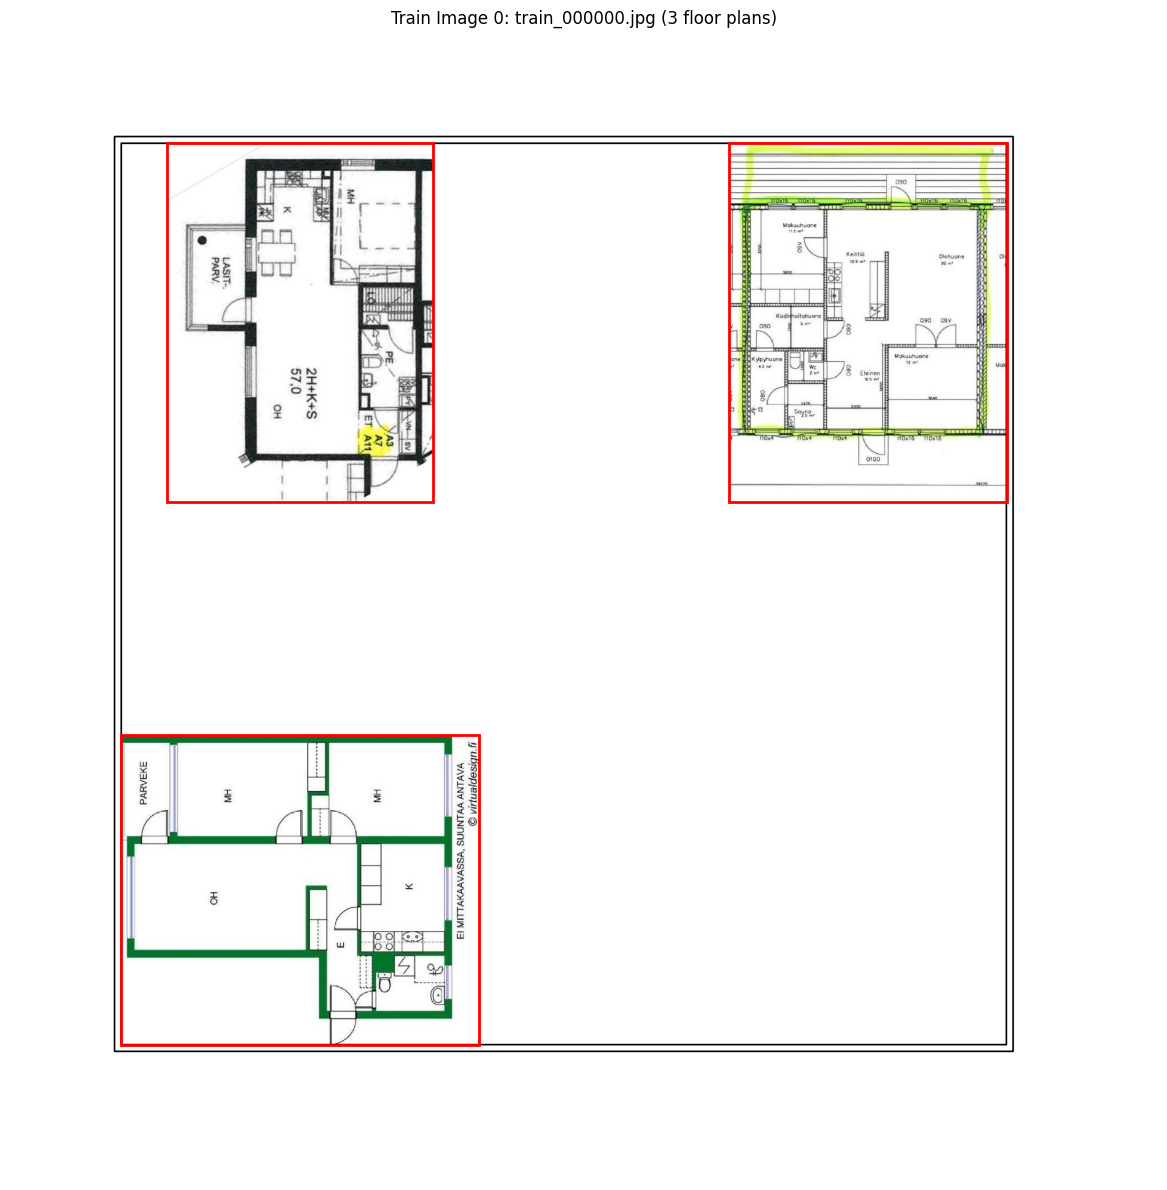

Image: train_000000.jpg
Size: 2048x2048
Number of floor plans: 3


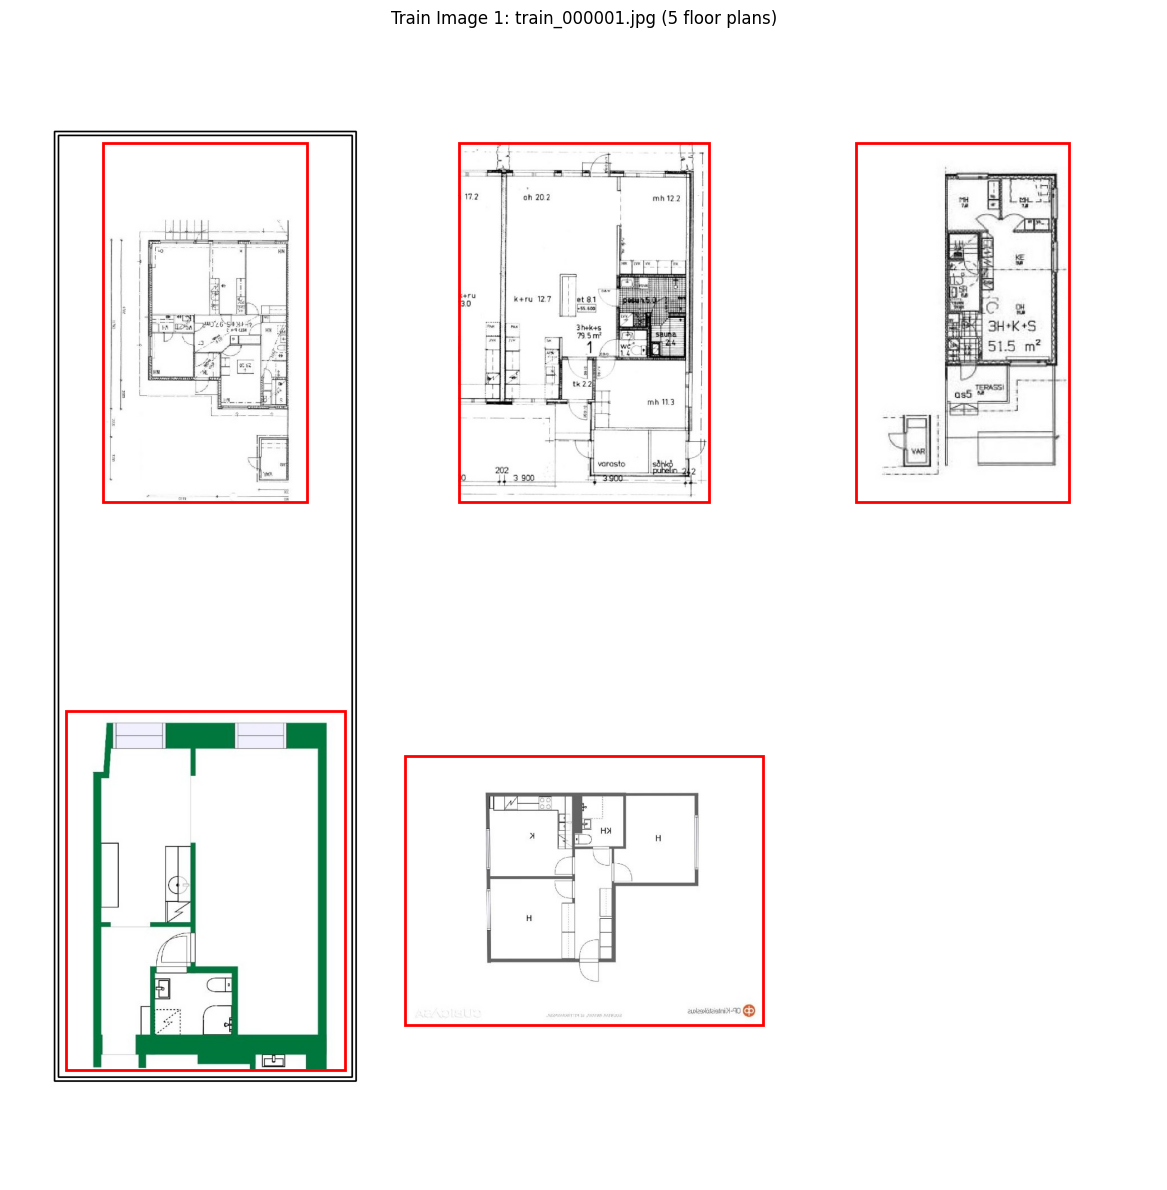

Image: train_000001.jpg
Size: 2048x2048
Number of floor plans: 5


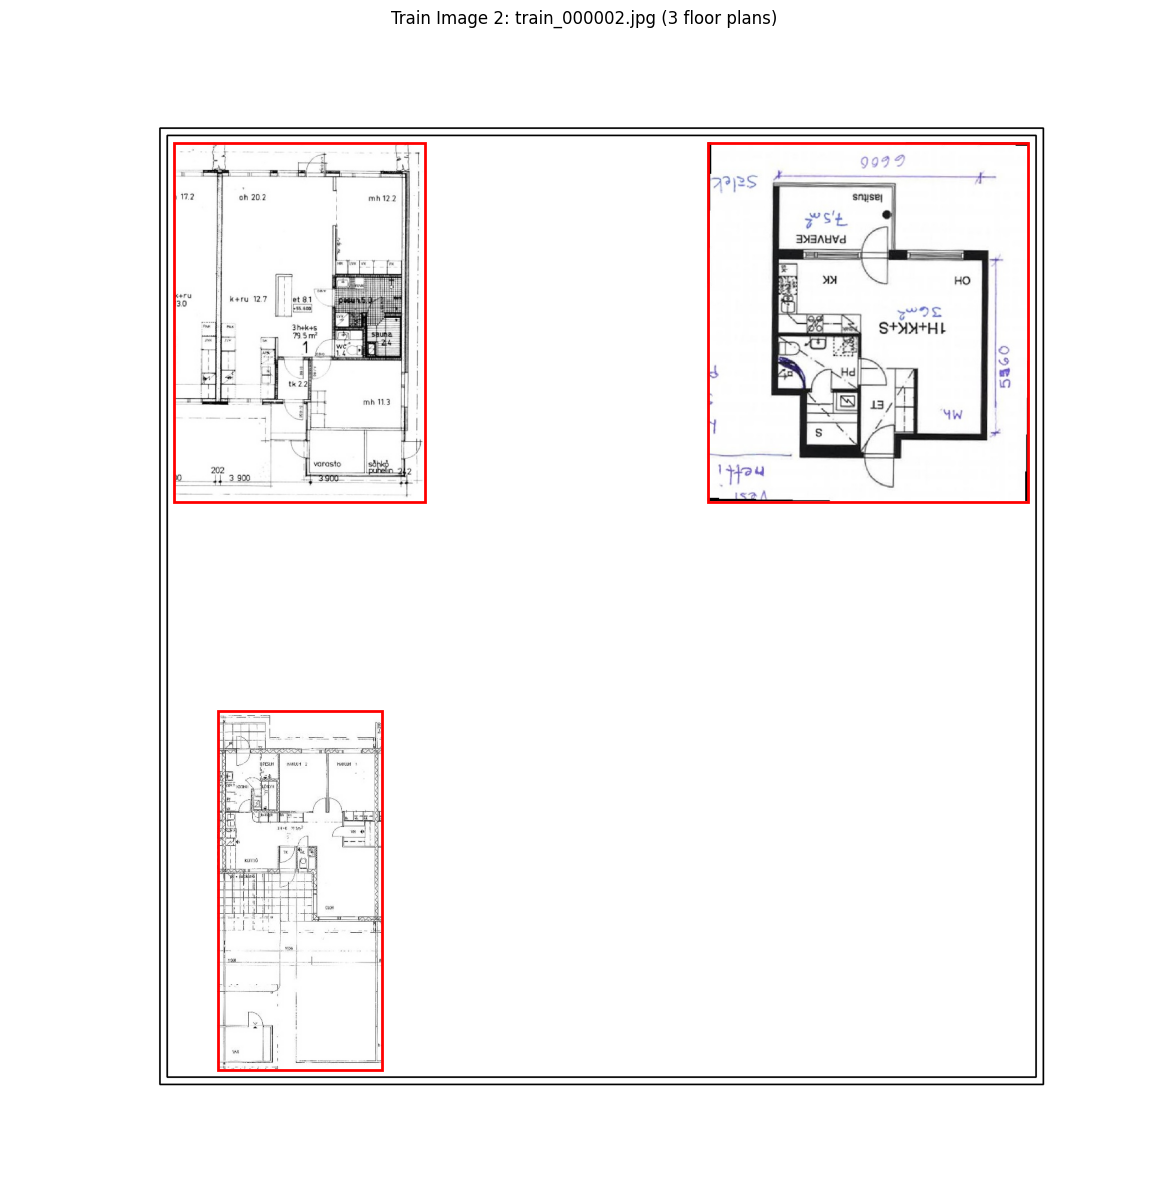

Image: train_000002.jpg
Size: 2048x2048
Number of floor plans: 3


In [86]:
# Visualize first 3 training images
for i in range(min(3, NUM_TRAIN_IMAGES)):
    visualize_sample_image('train', i)


In [87]:
from ultralytics import YOLO
import torch

# Sanity check: GPU
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Torch CUDA build:", torch.version.cuda)

CUDA available: True
GPU: NVIDIA GeForce RTX 5090
Torch CUDA build: 13.0


In [88]:

# Load YOLOv12x pretrained model
model = YOLO("../pretrained/yolo12x.pt")

# Train
results = model.train(
    data="../data/floor_plan_detection_dataset/data.yaml",   # path to your dataset YAML
    epochs=100,
    imgsz=640,
    batch=16,            # reduce if OOM
    device=0,           # GPU 0
    amp=True,           # mixed precision (recommended)
    workers=8,
    patience=50,
    project="runs/yolo12xtrain_floorplan_boundary",
    name="yolo12x_floorplan_boundary_exp"
)

New https://pypi.org/project/ultralytics/8.3.241 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.238 🚀 Python-3.10.19 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/floor_plan_detection_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../pretrained/yolo12x.pt, momentum=0.937, mosaic=1.0, multi_scale=Fal

In [1]:

import easyocr
from pdf2image import convert_from_path
from ultralytics import YOLO
import cv2
from PIL import Image
from pathlib import Path
import numpy as np

# Initialize EasyOCR reader (English language)
print("Initializing EasyOCR reader...")
reader = easyocr.Reader(['en'], gpu=True)  # Set gpu=False if no CUDA available
print("✓ EasyOCR reader initialized")

# Load trained floor plan boundary detection model
model = YOLO("runs/yolo12xtrain_floorplan_boundary/yolo12x_floorplan_boundary_exp2/weights/best.pt")

# Setup paths
pdf_folder = Path("../data")
pdf_file = pdf_folder / "example.pdf"
output_folder = Path("runs/predict/floor_plan_boundary_detection")
output_folder.mkdir(parents=True, exist_ok=True)

print(f"Processing: {pdf_file}")
print(f"Output folder: {output_folder}")


Initializing EasyOCR reader...
✓ EasyOCR reader initialized
Processing: ../data/example.pdf
Output folder: runs/predict/floor_plan_boundary_detection


In [2]:
# Convert PDF to PNG images (one per page)
print("\nConverting PDF to images...")
pages = convert_from_path(pdf_file, dpi=300)
print(f"✓ Converted {len(pages)} page(s)")

# Process each page
for page_num, page_img in enumerate(pages, start=1):
    print(f"\n{'='*60}")
    print(f"Processing Page {page_num}")
    print(f"{'='*60}")

    # Save original PNG
    png_path = output_folder / f"example_page_{page_num}.png"
    page_img.save(png_path)
    print(f"✓ Saved original PNG: {png_path.name}")

    # Run YOLO floor plan boundary detection
    print("Running floor plan boundary detection...")
    results = model.predict(
        source=str(png_path),
        imgsz=640,
        device=0,
        conf=0.80,
        save=False
    )

    # Get detections
    detections = results[0].boxes
    num_floor_plans = len(detections)
    print(f"✓ Detected {num_floor_plans} floor plan(s)")

    # Save annotated image with bounding boxes
    annot = results[0].plot()
    annot_rgb = cv2.cvtColor(annot, cv2.COLOR_BGR2RGB)
    annot_path = output_folder / f"example_page_{page_num}_annotated.png"
    Image.fromarray(annot_rgb).save(annot_path)
    print(f"✓ Saved annotated image: {annot_path.name}")

    # Extract and save individual floor plans
    img_np = np.array(page_img)
    img_height, img_width = img_np.shape[:2]

    for idx, box in enumerate(detections):
        # Get bounding box coordinates (xyxy format)
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        conf = box.conf[0].cpu().numpy()

        # Convert to integers
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

        # Crop floor plan
        floor_plan_crop = img_np[y1:y2, x1:x2]

        # Save cropped floor plan
        crop_path = output_folder / f"example_page_{page_num}_floorplan_{idx+1}.png"
        Image.fromarray(floor_plan_crop).save(crop_path)
        print(f"  Floor plan {idx+1}: {crop_path.name} (confidence: {conf:.3f})")

        # Run OCR on cropped floor plan using EasyOCR
        try:
            print(f"    Running OCR on floor plan {idx+1}...")
            # EasyOCR accepts numpy array, PIL image, or file path
            ocr_results = reader.readtext(floor_plan_crop)

            # Extract text from results
            text_lines = [detection[1] for detection in ocr_results]  # detection[1] is the text
            text = '\n'.join(text_lines)

            if text.strip():
                text_path = output_folder / f"example_page_{page_num}_floorplan_{idx+1}_ocr.txt"
                with open(text_path, 'w', encoding='utf-8') as f:
                    f.write(text)
                    # Also save detailed results with confidence scores
                    f.write("\n\n=== Detailed OCR Results ===\n")
                    for detection in ocr_results:
                        bbox, detected_text, confidence = detection
                        f.write(f"Text: {detected_text} (confidence: {confidence:.3f})\n")
                print(f"    ✓ OCR text saved: {text_path.name} ({len(text_lines)} text regions detected)")
            else:
                print(f"    ⚠ No text detected in floor plan {idx+1}")
        except Exception as e:
            print(f"    ⚠ OCR failed: {e}")

print(f"\n{'='*60}")
print("Processing complete!")
print(f"Results saved to: {output_folder.absolute()}")
print(f"{'='*60}")



Converting PDF to images...
✓ Converted 1 page(s)

Processing Page 1
✓ Saved original PNG: example_page_1.png
Running floor plan boundary detection...

image 1/1 /mnt/c/Users/ryan/Documents/GitHub/construction-ai/datascience/runs/predict/floor_plan_boundary_detection/example_page_1.png: 416x640 3 floor_plans, 25.3ms
Speed: 1.5ms preprocess, 25.3ms inference, 11.4ms postprocess per image at shape (1, 3, 416, 640)
✓ Detected 3 floor plan(s)
✓ Saved annotated image: example_page_1_annotated.png
  Floor plan 1: example_page_1_floorplan_1.png (confidence: 0.954)
    Running OCR on floor plan 1...
    ✓ OCR text saved: example_page_1_floorplan_1_ocr.txt (124 text regions detected)
  Floor plan 2: example_page_1_floorplan_2.png (confidence: 0.908)
    Running OCR on floor plan 2...
    ✓ OCR text saved: example_page_1_floorplan_2_ocr.txt (131 text regions detected)
  Floor plan 3: example_page_1_floorplan_3.png (confidence: 0.903)
    Running OCR on floor plan 3...
    ✓ OCR text saved: exam